# Task 2: Neural CTR Prediction

## Importing Libraries

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, 
    accuracy_score, 
    precision_recall_curve, 
    auc, 
    log_loss, 
    roc_curve
)
from sklearn.calibration import calibration_curve

## Loading the Data

In [44]:
# Set random seeds for exact reproducibility
np.random.seed(42)
torch.manual_seed(42)

train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

train_df.head()

,label,integer_feature_1,integer_feature_2,integer_feature_3,integer_feature_4,integer_feature_5,integer_feature_6,integer_feature_7,integer_feature_8,integer_feature_9,...,categorical_feature_17,categorical_feature_18,categorical_feature_19,categorical_feature_20,categorical_feature_21,categorical_feature_22,categorical_feature_23,categorical_feature_24,categorical_feature_25,categorical_feature_26
0,0,49.0,520.0,0.0,353.0,5.0,0.0,0.0,0,2,...,1f7fc70b,628f1b8d,9512c20b,c5362157,a9ad4e8e,2b6a4b2f,bc71cd9d,9f4102b0,ff654802,2f33557c
1,0,NaN,408.0,NaN,NaN,NaN,0.0,0.0,-1,1,...,NaN,a1eb1511,0a1d513f,7fdb0729,747f6ecc,62682372,NaN,401a16fe,30436bfc,b757e957
2,0,28.0,37.0,2.0,5.0,4.0,5.0,1.0,974,14,...,753da5f3,d9f758ff,9512c20b,682d90ba,09afda28,307a0f03,f942364c,16e6b497,57e36578,a7ab145d
3,0,1.0,603.0,1.0,NaN,1.0,0.0,0.0,13,1,...,NaN,b8170bba,108a0699,47849e55,73b3f46d,d994ba60,NaN,328e967b,ff654802,2ba8d787
4,0,NaN,525.0,3.0,8.0,126.0,1.0,0.0,10,11,...,753da5f3,b8170bba,55191c09,0e29b5da,0683bc6f,47b99d80,d2b125b2,00a688ec,30436bfc,b757e957


## Preprocessing of Data

In [45]:
num_cols = [f'integer_feature_{i}' for i in range(1, 14)]
cat_cols = [f'categorical_feature_{i}' for i in range(1, 27)]

# Handle Missing Numerical Values & Log Transform
for col in num_cols:
    median_val = train_df[col].median()
    train_df[col] = np.log1p(np.maximum(0, train_df[col].fillna(median_val)))
    test_df[col] = np.log1p(np.maximum(0, test_df[col].fillna(median_val)))

# Scale Numerical Features
scaler = StandardScaler()
X_num_train = scaler.fit_transform(train_df[num_cols])
X_num_test = scaler.transform(test_df[num_cols])

# Frequency Encoding for High-Cardinality Categorical Features
cat_dims = []
X_cat_train_list, X_cat_test_list = [], []

for col in cat_cols:
    train_df[col] = train_df[col].fillna('missing').astype(str)
    test_df[col] = test_df[col].fillna('missing').astype(str)
    
    top_cats = train_df[col].value_counts().nlargest(100).index
    le = {cat: i + 1 for i, cat in enumerate(top_cats)}  # 0 reserved for unknown/rare
    
    X_cat_train_list.append(train_df[col].map(le).fillna(0).astype(int).values)
    X_cat_test_list.append(test_df[col].map(le).fillna(0).astype(int).values)
    cat_dims.append(len(top_cats) + 1)

X_cat_train = np.column_stack(X_cat_train_list)
X_cat_test = np.column_stack(X_cat_test_list)

y_train = train_df['label'].values
y_test = test_df['label'].values

print(y_train)

[0 0 0 ... 0 0 0]


## Creating the Test Train Split
Using the typical 80/20 test-train split for optimal performance.\
Further converting them into tensors

In [34]:
# Splitting the train set into Train (80%) and Validation (20%) using stratification
X_num_tr, X_num_val, X_cat_tr, X_cat_val, y_tr, y_val = train_test_split(
    X_num_train, X_cat_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# Converting to PyTorch DataLoaders
train_loader = DataLoader(TensorDataset(torch.tensor(X_num_tr, dtype=torch.float32), 
                                         torch.tensor(X_cat_tr, dtype=torch.long), 
                                         torch.tensor(y_tr, dtype=torch.float32)), batch_size=256, shuffle=True)

val_loader = DataLoader(TensorDataset(torch.tensor(X_num_val, dtype=torch.float32), 
                                       torch.tensor(X_cat_val, dtype=torch.long), 
                                       torch.tensor(y_val, dtype=torch.float32)), batch_size=512, shuffle=False)

test_loader = DataLoader(TensorDataset(torch.tensor(X_num_test, dtype=torch.float32), 
                                        torch.tensor(X_cat_test, dtype=torch.long), 
                                        torch.tensor(y_test, dtype=torch.float32)), batch_size=512, shuffle=False)

## Architecture A : Vanilla Neural Network Model

In [35]:
class VanillaCTRNet(nn.Module):
    def __init__(self, num_features, cat_dims, emb_dim=8, hidden_units=[64, 32], dropout=0.2):
        super(VanillaCTRNet, self).__init__()
        self.embeddings = nn.ModuleList([nn.Embedding(num_embeddings=dim, embedding_dim=emb_dim) for dim in cat_dims])
        in_dim = num_features + len(cat_dims) * emb_dim
        
        layers = []
        for h_dim in hidden_units:
            layers.append(nn.Linear(in_dim, h_dim))
            layers.append(nn.BatchNorm1d(h_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            in_dim = h_dim
        layers.append(nn.Linear(in_dim, 1))
        self.mlp = nn.Sequential(*layers)
        
    def forward(self, x_num, x_cat):
        emb_outs = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)]
        x = torch.cat([x_num] + emb_outs, dim=1)
        return torch.sigmoid(self.mlp(x)).squeeze(-1)

## Architecture B : Deep & Cross Network (DCN)

In [ ]:
class CrossNetwork(nn.Module):
    def __init__(self, in_dim, num_layers=2):
        super(CrossNetwork, self).__init__()
        self.num_layers = num_layers
        self.weights = nn.ParameterList([nn.Parameter(torch.randn(in_dim, 1) * 0.01) for _ in range(num_layers)])
        self.biases = nn.ParameterList([nn.Parameter(torch.zeros(in_dim, 1)) for _ in range(num_layers)])

    def forward(self, x0):
        x_l = x0.unsqueeze(2)
        x0_col = x0.unsqueeze(2)
        for i in range(self.num_layers):
            xl_w = torch.matmul(x_l.transpose(1, 2), self.weights[i])
            x_l = x0_col * xl_w + self.biases[i].unsqueeze(0) + x_l
        return x_l.squeeze(2)

class DCN(nn.Module):
    def __init__(self, num_features, cat_dims, emb_dim=8, cross_layers=2, deep_units=[64, 32], dropout=0.2):
        super(DCN, self).__init__()
        self.embeddings = nn.ModuleList([nn.Embedding(num_embeddings=dim, embedding_dim=emb_dim) for dim in cat_dims])
        in_dim = num_features + len(cat_dims) * emb_dim
        
        self.cross_net = CrossNetwork(in_dim, num_layers=cross_layers)
        
        deep_layers = []
        d_in = in_dim
        for h_dim in deep_units:
            deep_layers.append(nn.Linear(d_in, h_dim))
            deep_layers.append(nn.BatchNorm1d(h_dim))
            deep_layers.append(nn.ReLU())
            deep_layers.append(nn.Dropout(dropout))
            d_in = h_dim
        self.deep_net = nn.Sequential(*deep_layers)
        self.final_linear = nn.Linear(in_dim + deep_units[-1], 1)

    def forward(self, x_num, x_cat):
        emb_outs = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)]
        x0 = torch.cat([x_num] + emb_outs, dim=1)
        cross_out = self.cross_net(x0)
        deep_out = self.deep_net(x0)
        return torch.sigmoid(self.final_linear(torch.cat([cross_out, deep_out], dim=1))).squeeze(-1)

## Training and Validation

In [38]:
def train_model(model, epochs=10, lr=0.001):
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    train_losses, val_losses, val_aucs = [], [], []
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for x_num, x_cat, y in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(x_num, x_cat), y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * x_num.size(0)
            
        train_loss = running_loss / len(train_loader.dataset)
        train_losses.append(train_loss)
        
        model.eval()
        val_loss, val_preds, val_targets = 0.0, [], []
        with torch.no_grad():
            for x_num, x_cat, y in val_loader:
                preds = model(x_num, x_cat)
                val_loss += criterion(preds, y).item() * x_num.size(0)
                val_preds.extend(preds.numpy())
                val_targets.extend(y.numpy())
                
        val_loss /= len(val_loader.dataset)
        val_auc = roc_auc_score(val_targets, val_preds)
        val_losses.append(val_loss)
        val_aucs.append(val_auc)
        print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val ROC-AUC: {val_auc:.4f}")
        
    return train_losses, val_losses, val_aucs

print("--- Training Vanilla Net (Small: [64, 32]) ---")
v_small = VanillaCTRNet(13, cat_dims, hidden_units=[64, 32])
vsmall_tr, vsmall_val, vsmall_auc = train_model(v_small)

print("\n--- Training Vanilla Net (Medium: [128, 64]) ---")
v_med = VanillaCTRNet(13, cat_dims, hidden_units=[128, 64])
vmed_tr, vmed_val, vmed_auc = train_model(v_med)

print("\n--- Training Deep & Cross Network (DCN) ---")
dcn = DCN(13, cat_dims, cross_layers=2, deep_units=[64, 32])
dcn_tr, dcn_val, dcn_auc = train_model(dcn)

# Selecting the best architecture based on Validation ROC-AUC
best_model = dcn

--- Training Vanilla Net (Small: [64, 32]) ---
Epoch 01 | Train Loss: 0.3519 | Val Loss: 0.1954 | Val ROC-AUC: 0.6431
Epoch 02 | Train Loss: 0.1620 | Val Loss: 0.1401 | Val ROC-AUC: 0.7154
Epoch 03 | Train Loss: 0.1402 | Val Loss: 0.1331 | Val ROC-AUC: 0.7110
Epoch 04 | Train Loss: 0.1338 | Val Loss: 0.1313 | Val ROC-AUC: 0.7226
Epoch 05 | Train Loss: 0.1315 | Val Loss: 0.1310 | Val ROC-AUC: 0.7260
Epoch 06 | Train Loss: 0.1283 | Val Loss: 0.1330 | Val ROC-AUC: 0.7063
Epoch 07 | Train Loss: 0.1256 | Val Loss: 0.1326 | Val ROC-AUC: 0.7222
Epoch 08 | Train Loss: 0.1224 | Val Loss: 0.1355 | Val ROC-AUC: 0.7025
Epoch 09 | Train Loss: 0.1206 | Val Loss: 0.1345 | Val ROC-AUC: 0.7092
Epoch 10 | Train Loss: 0.1176 | Val Loss: 0.1365 | Val ROC-AUC: 0.7039

--- Training Vanilla Net (Medium: [128, 64]) ---
Epoch 01 | Train Loss: 0.3185 | Val Loss: 0.1582 | Val ROC-AUC: 0.6886
Epoch 02 | Train Loss: 0.1446 | Val Loss: 0.1359 | Val ROC-AUC: 0.6987
Epoch 03 | Train Loss: 0.1350 | Val Loss: 0.1324 | 

## Test Evaluation and Mertric Plots

In [39]:
best_model.eval()
test_preds, test_targets = [], []
with torch.no_grad():
    for x_num, x_cat, y in test_loader:
        test_preds.extend(best_model(x_num, x_cat).numpy())
        test_targets.extend(y.numpy())

test_preds, test_targets = np.array(test_preds), np.array(test_targets)

# Calculate Core Required Metrics
test_roc_auc = roc_auc_score(test_targets, test_preds)
test_log_loss = log_loss(test_targets, test_preds)
precision, recall, thresholds = precision_recall_curve(test_targets, test_preds)
test_pr_auc = auc(recall, precision)

# Justified Threshold Metric: Finding threshold that maximizes F1-Score
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
best_f1 = f1_scores[best_idx]

test_binary_preds = (test_preds >= best_threshold).astype(int)
test_acc = accuracy_score(test_targets, test_binary_preds)

print(f"\n==========================================")
print(f"--- FINAL TEST EVALUATION (DCN Model) ---")
print(f"ROC-AUC Score : {test_roc_auc:.4f}")
print(f"PR-AUC Score  : {test_pr_auc:.4f}")
print(f"Log Loss      : {test_log_loss:.4f}")
print(f"Best Threshold: {best_threshold:.4f} (Max F1 Decision Boundary)")
print(f"F1 Score      : {best_f1:.4f}")
print(f"Accuracy      : {test_acc:.4f}")
print(f"==========================================\n")


--- FINAL TEST EVALUATION (DCN Model) ---
ROC-AUC Score : 0.6987
PR-AUC Score  : 0.0781
Log Loss      : 0.1431
Best Threshold: 0.0748 (Max F1 Decision Boundary)
F1 Score      : 0.1348
Accuracy      : 0.8434



## Plot 1: Learning Curves & Overfitting Investigation

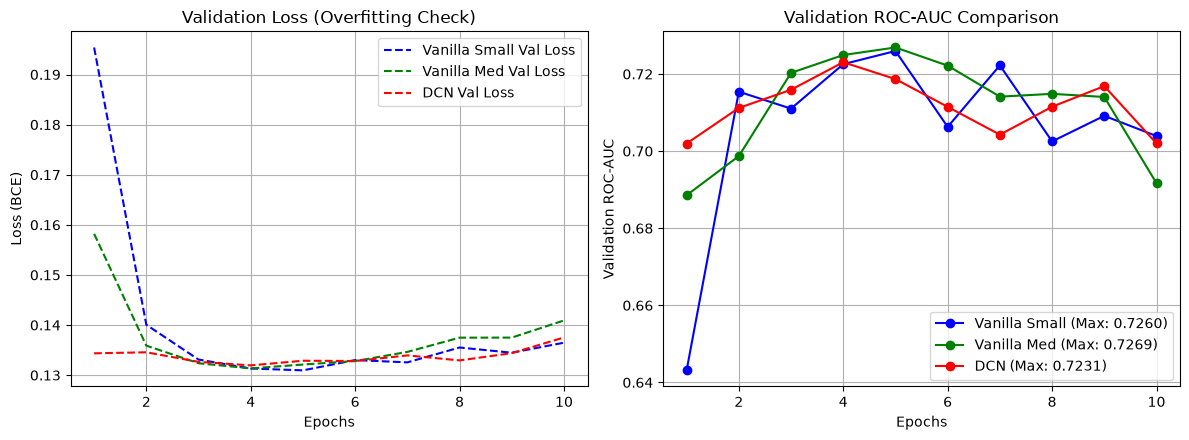

In [40]:
plt.figure(figsize=(12, 4.5))
plt.subplot(1, 2, 1)
plt.plot(range(1, 11), vsmall_val, 'b--', label='Vanilla Small Val Loss')
plt.plot(range(1, 11), vmed_val, 'g--', label='Vanilla Med Val Loss')
plt.plot(range(1, 11), dcn_val, 'r--', label='DCN Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (BCE)')
plt.title('Validation Loss (Overfitting Check)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, 11), vsmall_auc, 'b-o', label=f'Vanilla Small (Max: {max(vsmall_auc):.4f})')
plt.plot(range(1, 11), vmed_auc, 'g-o', label=f'Vanilla Med (Max: {max(vmed_auc):.4f})')
plt.plot(range(1, 11), dcn_auc, 'r-o', label=f'DCN (Max: {max(dcn_auc):.4f})')
plt.xlabel('Epochs')
plt.ylabel('Validation ROC-AUC')
plt.title('Validation ROC-AUC Comparison')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Plot 2: ROC, PR, and Calibration / Reliability Plots

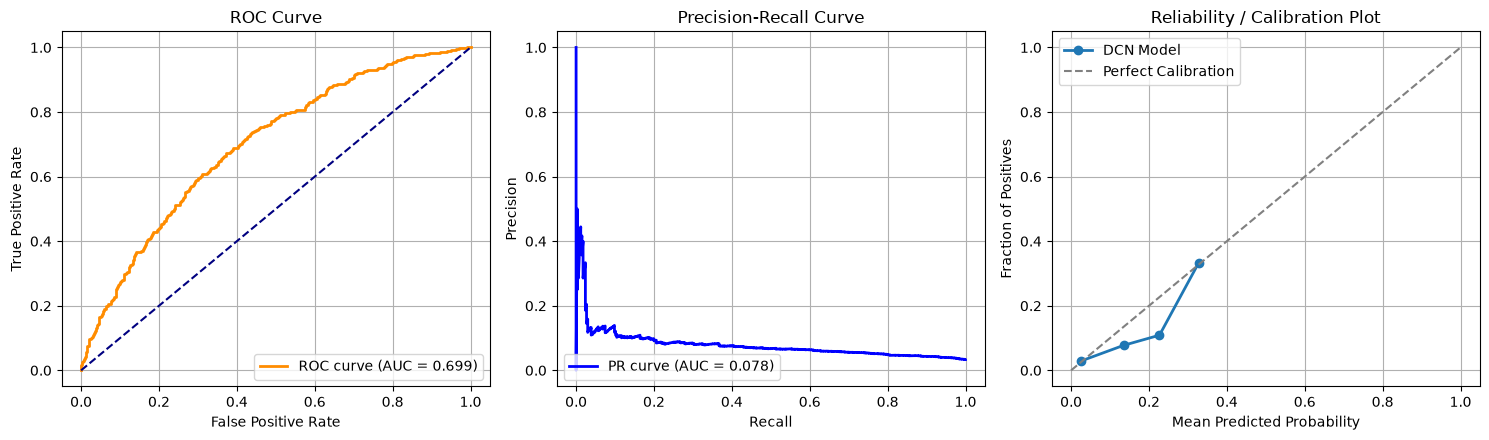

In [41]:
fpr, tpr, _ = roc_curve(test_targets, test_preds)
prob_true, prob_pred = calibration_curve(test_targets, test_preds, n_bins=10)

plt.figure(figsize=(15, 4.5))
plt.subplot(1, 3, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {test_roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(recall, precision, color='blue', lw=2, label=f'PR curve (AUC = {test_pr_auc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label='DCN Model')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Perfect Calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Reliability / Calibration Plot')
plt.legend(loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()